# Когда символьное представление временного ряда работает?

**Курсовая работа** — сравнение символьного и числового представлений для задачи классификации временных рядов.

**Методы:**
1. **Numeric PatchTST** — числовой baseline (raw signal → Transformer)
2. **SAX + Embedding + Transformer** — символьная последовательность через обучаемые эмбеддинги
3. **SAX Bag-of-Words + LogReg** — символьный словарный подход (TF-IDF + логистическая регрессия)
4. **BOSS (aeon)** — state-of-the-art символьный классификатор (Bag-of-SFA-Symbols)

**Данные:** 5 UCR датасетов + BTC (контрпример)

**Эксперименты:**
1. Сравнение 4 методов на 5 UCR датасетах
2. Noise sweep — устойчивость к шуму
3. BTC — когда символизация не работает

## 0. Установка пакетов

In [1]:
!pip install -q aeon tslearn pyts scikit-learn matplotlib seaborn yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.63.1 which is incompatible.


## 1. Импорты и конфигурация

In [2]:
import os, time, math, random, warnings, gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CFG = {
    "seeds": [42, 123, 777],
    "test_size": 0.2,
    "val_size": 0.15,
    # Transformer
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 2,
    "dropout": 0.1,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 30,
    "patience": 5,
    "batch_size": 64,
    "patch_len": 16,
    "patch_stride": 8,
    "amp": True,
    "grad_clip": 1.0,
    # SAX
    "sax_n_segments": 16,
    "sax_alphabet": 8,
    "sax_bow_window": 4,
    "sax_bow_word": 4,
    # BTC
    "btc_lookback": 64,
    "btc_horizon": 1,
}

RESULTS = []

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def add_result(experiment, method, dataset, metrics, extra=None):
    row = {"experiment": experiment, "method": method, "dataset": dataset, **metrics}
    if extra:
        row.update(extra)
    RESULTS.append(row)
    print(f"  {method:30s} | acc={metrics['accuracy']:.4f}  bal_acc={metrics['balanced_accuracy']:.4f}  f1={metrics['f1']:.4f}")

print("Конфигурация загружена")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Конфигурация загружена


## 2. Загрузка данных

### UCR датасеты
Выбраны датасеты, где символьные методы исторически показывают сильные результаты:
- **Coffee** — спектроскопия (28/28, 2 класса)
- **GunPoint** — жест рукой (50/150, 2 класса)
- **Trace** — синтетические сигналы (100/100, 4 класса)
- **TwoLeadECG** — электрокардиограмма (23/1139, 2 класса)
- **ECG5000** — электрокардиограмма (500/4500, 5 классов)

In [3]:
from aeon.datasets import load_classification

UCR_DATASETS = ["Coffee", "GunPoint", "Trace", "TwoLeadECG", "ECG5000"]

ucr_data = {}
for name in UCR_DATASETS:
    X_train, y_train = load_classification(name, split="train")
    X_test, y_test = load_classification(name, split="test")
    # aeon returns (n_samples, n_channels, length) — squeeze to (n_samples, length)
    X_train = X_train.squeeze(1) if X_train.ndim == 3 else X_train
    X_test = X_test.squeeze(1) if X_test.ndim == 3 else X_test
    # Convert labels to int
    classes = sorted(set(y_train))
    label_map = {c: i for i, c in enumerate(classes)}
    y_train = np.array([label_map[c] for c in y_train])
    y_test = np.array([label_map[c] for c in y_test])
    ucr_data[name] = {
        "X_train": X_train.astype(np.float32),
        "X_test": X_test.astype(np.float32),
        "y_train": y_train,
        "y_test": y_test,
        "n_classes": len(classes),
    }
    print(f"{name:15s}: train={X_train.shape}, test={X_test.shape}, classes={len(classes)}, length={X_train.shape[1]}")

print("\nВсе UCR датасеты загружены")

Coffee         : train=(28, 286), test=(28, 286), classes=2, length=286
GunPoint       : train=(50, 150), test=(150, 150), classes=2, length=150
Trace          : train=(100, 275), test=(100, 275), classes=4, length=275
TwoLeadECG     : train=(23, 82), test=(1139, 82), classes=2, length=82
ECG5000        : train=(500, 140), test=(4500, 140), classes=5, length=140

Все UCR датасеты загружены


### BTC данные (контрпример)

In [4]:
import yfinance as yf

btc_raw = yf.download("BTC-USD", period="2y", interval="1h", progress=False)
print(f"BTC: {len(btc_raw)} часовых свечей")

def make_btc_windows(df, lookback=64, horizon=1):
    close = df["Close"].values.astype(np.float32).flatten()
    X, y = [], []
    for i in range(lookback, len(close) - horizon):
        window = close[i - lookback : i]
        # z-normalize window
        mu, sigma = window.mean(), window.std() + 1e-8
        X.append((window - mu) / sigma)
        future_ret = np.log(close[i + horizon - 1] / close[i - 1])
        y.append(1 if future_ret > 0 else 0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_btc, y_btc = make_btc_windows(btc_raw, CFG["btc_lookback"], CFG["btc_horizon"])
print(f"BTC windows: X={X_btc.shape}, y distribution: {Counter(y_btc)}")

BTC: 17365 часовых свечей
BTC windows: X=(17300, 64), y distribution: Counter({np.int64(1): 8750, np.int64(0): 8550})


## 3. Модели

### 3.1 PatchTST (числовой baseline)
Маленький трансформер: d_model=64, 2 слоя, 4 головы. Подходит для бесплатного Colab.

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class PatchTSTClassifier(nn.Module):
    """Маленький PatchTST для классификации."""
    def __init__(self, input_dim, seq_len, n_classes, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1, patch_len=16, patch_stride=8):
        super().__init__()
        self.patch_len = patch_len
        self.patch_stride = patch_stride
        self.n_classes = n_classes
        self.patch_proj = nn.Linear(patch_len * input_dim, d_model)
        self.pos = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        out_dim = 1 if n_classes == 2 else n_classes
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, out_dim))

    def forward(self, x):
        # x: (B, L, F)
        B, L, F = x.shape
        if L < self.patch_len:
            pad = torch.zeros(B, self.patch_len - L, F, device=x.device)
            x = torch.cat([pad, x], dim=1)
            L = x.size(1)
        patches = x.unfold(1, self.patch_len, self.patch_stride)  # (B, n_patches, F, patch_len)
        patches = patches.permute(0, 1, 3, 2).contiguous().view(B, -1, self.patch_len * F)
        z = self.encoder(self.pos(self.patch_proj(patches)))
        logits = self.head(z[:, -1, :])
        return logits.squeeze(-1)


class SymbolicPatchTSTClassifier(nn.Module):
    """PatchTST с Embedding входом для символьных последовательностей.
    ВАЖНО: символы подаются через nn.Embedding, а НЕ как float."""
    def __init__(self, vocab_size, seq_len, n_classes, embed_dim=32,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1,
                 patch_len=16, patch_stride=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.backbone = PatchTSTClassifier(
            input_dim=embed_dim, seq_len=seq_len, n_classes=n_classes,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers,
            dropout=dropout, patch_len=patch_len, patch_stride=patch_stride,
        )

    def forward(self, token_ids):
        # token_ids: (B, L) long tensor
        x = self.embedding(token_ids)  # (B, L, embed_dim)
        return self.backbone(x)


print("Модели определены")

Модели определены


### 3.2 Функции обучения и предсказания

In [6]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        if self.X.ndim == 2:
            self.X = self.X.unsqueeze(-1)  # (N, L) -> (N, L, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class TokenDataset(Dataset):
    def __init__(self, token_ids, y):
        self.tokens = torch.tensor(token_ids, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        return self.tokens[idx], self.y[idx]


def train_model(model, train_loader, val_loader, cfg, binary=True):
    model = model.to(DEVICE)
    if binary:
        loss_fn = nn.BCEWithLogitsLoss()
    else:
        loss_fn = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scaler = GradScaler("cuda", enabled=(cfg["amp"] and DEVICE == "cuda"))
    best_val, best_state, wait = 1e9, None, 0

    for epoch in range(cfg["epochs"]):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=(cfg["amp"] and DEVICE == "cuda")):
                logits = model(xb)
                if binary:
                    loss = loss_fn(logits.float(), yb.float())
                else:
                    loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            if cfg["grad_clip"]:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(opt)
            scaler.update()

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with autocast("cuda", enabled=(cfg["amp"] and DEVICE == "cuda")):
                    logits = model(xb)
                    if binary:
                        loss = loss_fn(logits.float(), yb.float())
                    else:
                        loss = loss_fn(logits, yb)
                val_losses.append(loss.item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def predict(model, loader, binary=True):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(xb)
            if binary:
                preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            else:
                preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)


print("Функции обучения определены")

Функции обучения определены


## 4. Символьные пайплайны

### 4.1 SAX (Symbolic Aggregate approXimation)
Правильная реализация: **fit на train, transform на test тем же кодбуком**.

In [7]:
from tslearn.piecewise import SymbolicAggregateApproximation

def sax_fit_transform(X_train, X_test, n_segments=16, alphabet_size=8):
    """
    Правильный SAX пайплайн:
    1. Fit на train (определяем breakpoints)
    2. Transform train и test одним кодбуком
    Возвращает integer token IDs (0 = PAD, 1..alphabet_size = символы)
    """
    # tslearn SAX ожидает (n_samples, length, 1)
    Xtr = X_train[:, :, np.newaxis] if X_train.ndim == 2 else X_train
    Xte = X_test[:, :, np.newaxis] if X_test.ndim == 2 else X_test

    sax = SymbolicAggregateApproximation(
        n_segments=n_segments,
        alphabet_size_avg=alphabet_size,
    )
    sax.fit(Xtr)
    sax_train = sax.transform(Xtr)  # (N, n_segments, 1)
    sax_test = sax.transform(Xte)

    # Преобразуем в integer IDs (сдвигаем на 1, чтобы 0 = PAD)
    train_ids = sax_train.squeeze(-1).astype(np.int64) + 1
    test_ids = sax_test.squeeze(-1).astype(np.int64) + 1
    vocab_size = alphabet_size + 2  # 0=PAD, 1..alphabet=symbols, +1 запас

    return train_ids, test_ids, vocab_size


print("SAX пайплайн определён")

SAX пайплайн определён


### 4.2 SAX Bag-of-Words
Символьная последовательность → скользящие окна → слова → TF-IDF вектор → LogReg.
Это подход в стиле BOSS/WEASEL, но проще.

In [8]:
from pyts.bag_of_words import BagOfWords as PyTSBagOfWords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

def sax_bow_classify(X_train, y_train, X_test, y_test, seed=42,
                     window_size=4, word_size=4, n_bins=4):
    """SAX Bag-of-Words + TF-IDF + Logistic Regression."""
    # pyts BagOfWords: fit на train, transform обоих
    bow = PyTSBagOfWords(
        window_size=window_size,
        word_size=word_size,
        n_bins=n_bins,
        numerosity_reduction=True,
    )
    bow_train = bow.fit_transform(X_train)  # returns list of strings
    bow_test = bow.transform(X_test)

    # TF-IDF + LogReg
    tfidf = TfidfVectorizer(analyzer="word", token_pattern=r"\S+")
    X_tr_tfidf = tfidf.fit_transform(bow_train)
    X_te_tfidf = tfidf.transform(bow_test)

    clf = LogisticRegression(max_iter=2000, random_state=seed, C=1.0)
    clf.fit(X_tr_tfidf, y_train)
    y_pred = clf.predict(X_te_tfidf)
    return compute_metrics(y_test, y_pred)


print("SAX Bag-of-Words пайплайн определён")

SAX Bag-of-Words пайплайн определён


### 4.3 BOSS (Bag-of-SFA-Symbols) из aeon
State-of-the-art символьный классификатор. Использует:
- SFA (Symbolic Fourier Approximation) вместо SAX
- Скользящие окна
- Гистограммы слов
- 1-NN или ансамбль

In [9]:
from aeon.classification.dictionary_based import BOSSEnsemble, ContractableBOSS

def boss_classify(X_train, y_train, X_test, y_test, seed=42, max_ensemble_size=50):
    """BOSS ансамбль из aeon. Работает на CPU, не требует GPU."""
    # aeon ожидает (n_samples, n_channels, length)
    Xtr = X_train[:, np.newaxis, :] if X_train.ndim == 2 else X_train
    Xte = X_test[:, np.newaxis, :] if X_test.ndim == 2 else X_test

    # ContractableBOSS — быстрая версия BOSS с ограничением по времени
    boss = ContractableBOSS(
        n_parameter_samples=max_ensemble_size,
        random_state=seed,
    )
    boss.fit(Xtr, y_train)
    y_pred = boss.predict(Xte)
    return compute_metrics(y_test, y_pred)


print("BOSS классификатор определён")

BOSS классификатор определён


### 4.4 Запуск всех методов на одном датасете

In [10]:
def run_all_methods(X_train, y_train, X_test, y_test, dataset_name,
                    experiment_name, n_classes, seeds=None, cfg=None):
    """Запускает все 4 метода на одном датасете и сохраняет результаты."""
    if cfg is None:
        cfg = CFG
    if seeds is None:
        seeds = cfg["seeds"]
    binary = (n_classes == 2)
    seq_len = X_train.shape[1]

    print(f"\n{'='*60}")
    print(f"Датасет: {dataset_name} (train={len(X_train)}, test={len(X_test)}, classes={n_classes}, len={seq_len})")
    print(f"{'='*60}")

    # ── 1. Majority baseline ──
    majority_class = Counter(y_train).most_common(1)[0][0]
    y_majority = np.full_like(y_test, majority_class)
    m = compute_metrics(y_test, y_majority)
    add_result(experiment_name, "Majority", dataset_name, m)

    # ── 2. Numeric PatchTST ──
    all_m = []
    for seed in seeds:
        set_seed(seed)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=cfg["val_size"], random_state=seed, stratify=y_train
        )
        tr_ds = TSDataset(X_tr, y_tr)
        val_ds = TSDataset(X_val, y_val)
        te_ds = TSDataset(X_test, y_test)
        tr_loader = DataLoader(tr_ds, batch_size=cfg["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"])
        te_loader = DataLoader(te_ds, batch_size=cfg["batch_size"])

        pl = min(cfg["patch_len"], seq_len)
        ps = min(cfg["patch_stride"], seq_len)
        model = PatchTSTClassifier(
            input_dim=1, seq_len=seq_len, n_classes=n_classes,
            d_model=cfg["d_model"], n_heads=cfg["n_heads"],
            n_layers=cfg["n_layers"], dropout=cfg["dropout"],
            patch_len=pl, patch_stride=ps,
        )
        model = train_model(model, tr_loader, val_loader, cfg, binary=binary)
        y_true, y_pred = predict(model, te_loader, binary=binary)
        all_m.append(compute_metrics(y_true, y_pred))
        del model; gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()

    avg = {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}
    add_result(experiment_name, "Numeric PatchTST", dataset_name, avg)

    # ── 3. SAX + Embedding + PatchTST ──
    n_seg = min(cfg["sax_n_segments"], seq_len // 2)
    all_m = []
    for seed in seeds:
        set_seed(seed)
        sax_tr, sax_te, vocab_size = sax_fit_transform(
            X_train, X_test, n_segments=n_seg, alphabet_size=cfg["sax_alphabet"]
        )
        sax_tr_split, sax_val, y_tr, y_val = train_test_split(
            sax_tr, y_train, test_size=cfg["val_size"], random_state=seed, stratify=y_train
        )
        tr_ds = TokenDataset(sax_tr_split, y_tr)
        val_ds = TokenDataset(sax_val, y_val)
        te_ds = TokenDataset(sax_te, y_test)
        tr_loader = DataLoader(tr_ds, batch_size=cfg["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"])
        te_loader = DataLoader(te_ds, batch_size=cfg["batch_size"])

        sax_seq_len = sax_tr.shape[1]
        spl = min(cfg["patch_len"], sax_seq_len)
        sps = min(cfg["patch_stride"], sax_seq_len)
        model = SymbolicPatchTSTClassifier(
            vocab_size=vocab_size, seq_len=sax_seq_len, n_classes=n_classes,
            embed_dim=32, d_model=cfg["d_model"], n_heads=cfg["n_heads"],
            n_layers=cfg["n_layers"], dropout=cfg["dropout"],
            patch_len=spl, patch_stride=sps,
        )
        model = train_model(model, tr_loader, val_loader, cfg, binary=binary)
        y_true, y_pred = predict(model, te_loader, binary=binary)
        all_m.append(compute_metrics(y_true, y_pred))
        del model; gc.collect()
        if DEVICE == "cuda": torch.cuda.empty_cache()

    avg = {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}
    add_result(experiment_name, "SAX+Embed+Transformer", dataset_name, avg)

    # ── 4. SAX Bag-of-Words + LogReg ──
    all_m = []
    for seed in seeds:
        set_seed(seed)
        ws = min(cfg["sax_bow_window"], seq_len // 4)
        ww = min(cfg["sax_bow_word"], ws)
        m = sax_bow_classify(X_train, y_train, X_test, y_test,
                             seed=seed, window_size=ws, word_size=ww,
                             n_bins=cfg["sax_alphabet"])
        all_m.append(m)
    avg = {k: np.mean([x[k] for x in all_m]) for k in all_m[0]}
    add_result(experiment_name, "SAX-BoW+LogReg", dataset_name, avg)

    # ── 5. BOSS (aeon) ──
    m = boss_classify(X_train, y_train, X_test, y_test, seed=42)
    add_result(experiment_name, "BOSS (aeon)", dataset_name, m)


print("Функция run_all_methods определена")

Функция run_all_methods определена


## 5. Эксперимент 1: Сравнение на UCR датасетах

Запускаем все 4 метода на 5 UCR датасетах, где символьные методы исторически показывают
сильные результаты (BOSS/WEASEL конкурируют с InceptionTime на Coffee, GunPoint, Trace, TwoLeadECG).

In [11]:
print("=" * 70)
print("ЭКСПЕРИМЕНТ 1: Сравнение методов на UCR датасетах")
print("=" * 70)

t0 = time.time()
for name in UCR_DATASETS:
    d = ucr_data[name]
    run_all_methods(
        d["X_train"], d["y_train"], d["X_test"], d["y_test"],
        dataset_name=name,
        experiment_name="UCR",
        n_classes=d["n_classes"],
    )

print(f"\nЭксперимент 1 завершён за {time.time() - t0:.0f} сек")

ЭКСПЕРИМЕНТ 1: Сравнение методов на UCR датасетах

Датасет: Coffee (train=28, test=28, classes=2, len=286)
  Majority                       | acc=0.5357  bal_acc=0.5000  f1=0.3488
  Numeric PatchTST               | acc=0.4881  bal_acc=0.5000  f1=0.3277
  SAX+Embed+Transformer          | acc=0.8929  bal_acc=0.8897  f1=0.8916
  SAX-BoW+LogReg                 | acc=0.6429  bal_acc=0.6513  f1=0.6410
  BOSS (aeon)                    | acc=1.0000  bal_acc=1.0000  f1=1.0000

Датасет: GunPoint (train=50, test=150, classes=2, len=150)
  Majority                       | acc=0.4933  bal_acc=0.5000  f1=0.3304
  Numeric PatchTST               | acc=0.6844  bal_acc=0.6845  f1=0.6638
  SAX+Embed+Transformer          | acc=0.9044  bal_acc=0.9050  f1=0.9043
  SAX-BoW+LogReg                 | acc=0.8333  bal_acc=0.8327  f1=0.8327
  BOSS (aeon)                    | acc=0.9933  bal_acc=0.9932  f1=0.9933

Датасет: Trace (train=100, test=100, classes=4, len=275)
  Majority                       | acc=0.1900

### Результаты эксперимента 1


ACCURACY по датасетам (↑ лучше)
dataset                Coffee  GunPoint   Trace  TwoLeadECG  ECG5000  Средний ранг
method                                                                            
BOSS (aeon)            1.0000    0.9933  1.0000      0.9763   0.9451           1.0
SAX+Embed+Transformer  0.8929    0.9044  0.8367      0.6675   0.9197           2.4
SAX-BoW+LogReg         0.6429    0.8333  0.5400      0.6690   0.7944           3.2
Numeric PatchTST       0.4881    0.6844  0.7133      0.5721   0.9365           3.6
Majority               0.5357    0.4933  0.1900      0.4996   0.5838           4.8


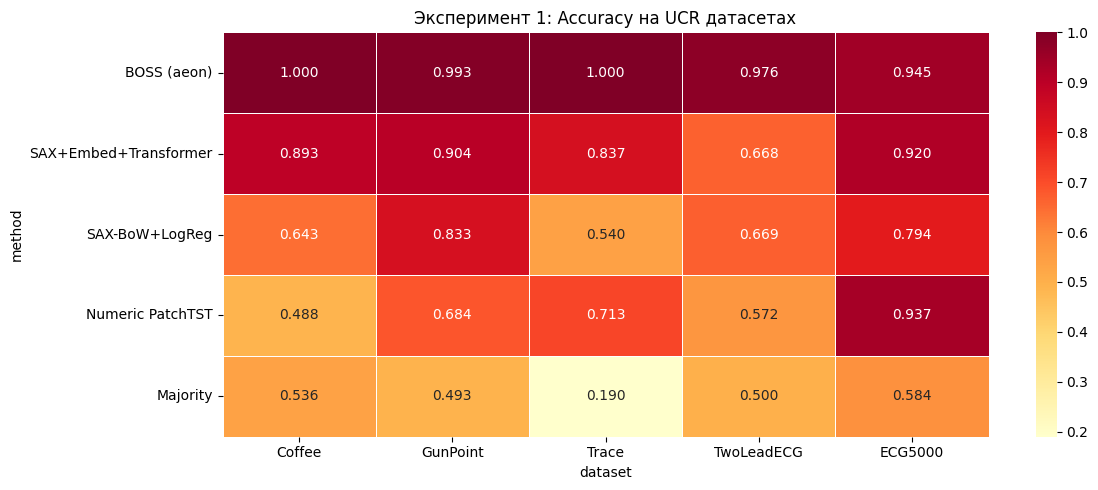

In [12]:
df1 = pd.DataFrame([r for r in RESULTS if r["experiment"] == "UCR"])
pivot1 = df1.pivot_table(index="method", columns="dataset", values="accuracy", aggfunc="first")
pivot1 = pivot1[UCR_DATASETS]  # порядок столбцов

# Считаем средний ранг
ranks = pivot1.rank(ascending=False, method="min")
pivot1["Средний ранг"] = ranks.mean(axis=1)
pivot1 = pivot1.sort_values("Средний ранг")

print("\n" + "=" * 70)
print("ACCURACY по датасетам (↑ лучше)")
print("=" * 70)
print(pivot1.round(4).to_string())

# Тепловая карта
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot1.drop(columns=["Средний ранг"]), annot=True, fmt=".3f",
            cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Эксперимент 1: Accuracy на UCR датасетах")
plt.tight_layout()
plt.savefig("exp1_ucr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Эксперимент 2: Устойчивость к шуму (Noise Sweep)

**Гипотеза:** символьное представление более устойчиво к гауссову шуму,
потому что квантование работает как low-pass фильтр.

Используем датасет **ECG5000** (наибольший ECG в нашей выборке).
Добавляем гауссов шум с нарастающим σ и замеряем деградацию accuracy.

In [13]:
noise_levels = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
noise_results = []
ecg_d = ucr_data["ECG5000"]
seed = 42

print("=" * 70)
print("ЭКСПЕРИМЕНТ 2: Noise Sweep на ECG5000")
print("=" * 70)

t0 = time.time()
for sigma in noise_levels:
    print(f"\n--- σ = {sigma} ---")
    set_seed(seed)

    # Добавляем шум
    np.random.seed(seed)
    X_tr_noisy = ecg_d["X_train"] + np.random.normal(0, sigma, ecg_d["X_train"].shape).astype(np.float32)
    X_te_noisy = ecg_d["X_test"] + np.random.normal(0, sigma, ecg_d["X_test"].shape).astype(np.float32)
    y_tr, y_te = ecg_d["y_train"], ecg_d["y_test"]
    n_classes = ecg_d["n_classes"]
    binary = (n_classes == 2)
    seq_len = X_tr_noisy.shape[1]

    # ── Numeric PatchTST ──
    set_seed(seed)
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_tr_noisy, y_tr, test_size=0.15, random_state=seed, stratify=y_tr
    )
    tr_loader = DataLoader(TSDataset(X_tr_s, y_tr_s), batch_size=CFG["batch_size"], shuffle=True)
    val_loader = DataLoader(TSDataset(X_val_s, y_val_s), batch_size=CFG["batch_size"])
    te_loader = DataLoader(TSDataset(X_te_noisy, y_te), batch_size=CFG["batch_size"])
    pl = min(CFG["patch_len"], seq_len)
    ps = min(CFG["patch_stride"], seq_len)
    model = PatchTSTClassifier(1, seq_len, n_classes, CFG["d_model"], CFG["n_heads"],
                                CFG["n_layers"], CFG["dropout"], pl, ps)
    model = train_model(model, tr_loader, val_loader, CFG, binary=binary)
    _, y_pred = predict(model, te_loader, binary=binary)
    m_num = compute_metrics(y_te, y_pred)
    noise_results.append({"sigma": sigma, "method": "Numeric PatchTST", **m_num})
    print(f"  Numeric PatchTST:       acc={m_num['accuracy']:.4f}")
    del model; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()

    # ── SAX + Embedding + Transformer ──
    set_seed(seed)
    n_seg = min(CFG["sax_n_segments"], seq_len // 2)
    sax_tr, sax_te, vocab_size = sax_fit_transform(X_tr_noisy, X_te_noisy, n_seg, CFG["sax_alphabet"])
    sax_tr_s, sax_val_s, y_tr_s, y_val_s = train_test_split(
        sax_tr, y_tr, test_size=0.15, random_state=seed, stratify=y_tr
    )
    tr_loader = DataLoader(TokenDataset(sax_tr_s, y_tr_s), batch_size=CFG["batch_size"], shuffle=True)
    val_loader = DataLoader(TokenDataset(sax_val_s, y_val_s), batch_size=CFG["batch_size"])
    te_loader = DataLoader(TokenDataset(sax_te, y_te), batch_size=CFG["batch_size"])
    sax_seq_len = sax_tr.shape[1]
    spl = min(CFG["patch_len"], sax_seq_len)
    sps = min(CFG["patch_stride"], sax_seq_len)
    model = SymbolicPatchTSTClassifier(vocab_size, sax_seq_len, n_classes, 32,
                                        CFG["d_model"], CFG["n_heads"], CFG["n_layers"],
                                        CFG["dropout"], spl, sps)
    model = train_model(model, tr_loader, val_loader, CFG, binary=binary)
    _, y_pred = predict(model, te_loader, binary=binary)
    m_sax = compute_metrics(y_te, y_pred)
    noise_results.append({"sigma": sigma, "method": "SAX+Embed+Transformer", **m_sax})
    print(f"  SAX+Embed+Transformer:  acc={m_sax['accuracy']:.4f}")
    del model; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()

    # ── SAX-BoW + LogReg ──
    ws = min(CFG["sax_bow_window"], seq_len // 4)
    ww = min(CFG["sax_bow_word"], ws)
    m_bow = sax_bow_classify(X_tr_noisy, y_tr, X_te_noisy, y_te,
                             seed=seed, window_size=ws, word_size=ww, n_bins=CFG["sax_alphabet"])
    noise_results.append({"sigma": sigma, "method": "SAX-BoW+LogReg", **m_bow})
    print(f"  SAX-BoW+LogReg:         acc={m_bow['accuracy']:.4f}")

    # ── BOSS ──
    m_boss = boss_classify(X_tr_noisy, y_tr, X_te_noisy, y_te, seed=seed)
    noise_results.append({"sigma": sigma, "method": "BOSS (aeon)", **m_boss})
    print(f"  BOSS (aeon):            acc={m_boss['accuracy']:.4f}")

print(f"\nЭксперимент 2 завершён за {time.time() - t0:.0f} сек")

ЭКСПЕРИМЕНТ 2: Noise Sweep на ECG5000

--- σ = 0.0 ---
  Numeric PatchTST:       acc=0.9344
  SAX+Embed+Transformer:  acc=0.9213
  SAX-BoW+LogReg:         acc=0.7944
  BOSS (aeon):            acc=0.9451

--- σ = 0.1 ---
  Numeric PatchTST:       acc=0.9349
  SAX+Embed+Transformer:  acc=0.9147
  SAX-BoW+LogReg:         acc=0.7040
  BOSS (aeon):            acc=0.9420

--- σ = 0.3 ---
  Numeric PatchTST:       acc=0.9336
  SAX+Embed+Transformer:  acc=0.9091
  SAX-BoW+LogReg:         acc=0.6296
  BOSS (aeon):            acc=0.9278

--- σ = 0.5 ---
  Numeric PatchTST:       acc=0.9287
  SAX+Embed+Transformer:  acc=0.8989
  SAX-BoW+LogReg:         acc=0.6102
  BOSS (aeon):            acc=0.9189

--- σ = 0.7 ---
  Numeric PatchTST:       acc=0.9242
  SAX+Embed+Transformer:  acc=0.9000
  SAX-BoW+LogReg:         acc=0.5911
  BOSS (aeon):            acc=0.9020

--- σ = 1.0 ---
  Numeric PatchTST:       acc=0.9118
  SAX+Embed+Transformer:  acc=0.8704
  SAX-BoW+LogReg:         acc=0.5811
  BOSS (a

### Кривые деградации

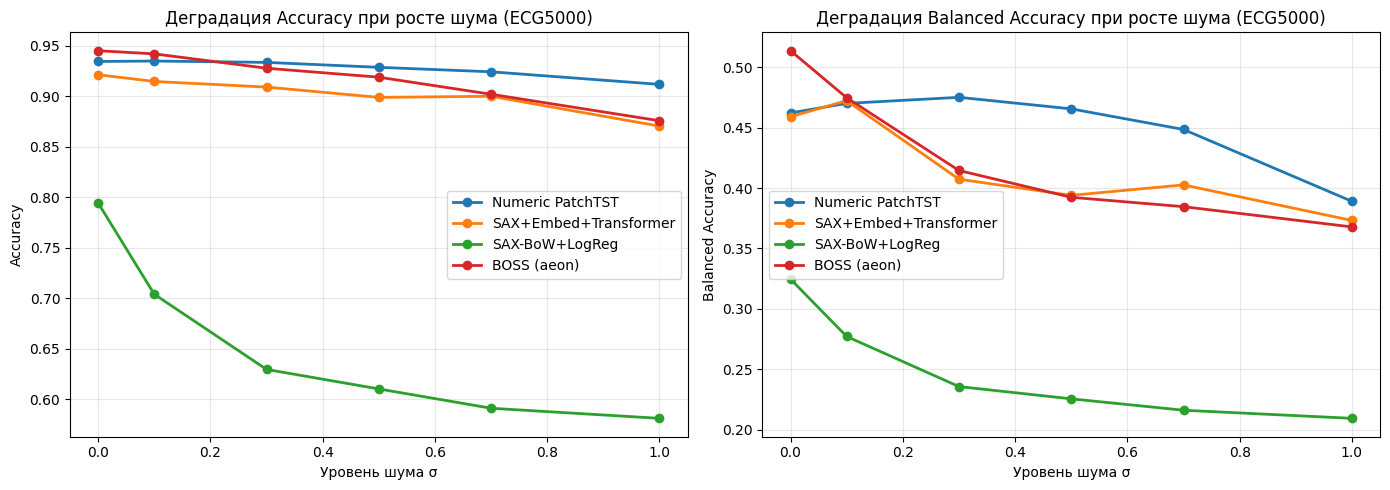


Accuracy при разных уровнях шума:
sigma                     0.0     0.1     0.3     0.5     0.7     1.0
method                                                               
BOSS (aeon)            0.9451  0.9420  0.9278  0.9189  0.9020  0.8758
Numeric PatchTST       0.9344  0.9349  0.9336  0.9287  0.9242  0.9118
SAX+Embed+Transformer  0.9213  0.9147  0.9091  0.8989  0.9000  0.8704
SAX-BoW+LogReg         0.7944  0.7040  0.6296  0.6102  0.5911  0.5811


In [14]:
noise_df = pd.DataFrame(noise_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in noise_df["method"].unique():
    sub = noise_df[noise_df["method"] == method]
    axes[0].plot(sub["sigma"], sub["accuracy"], marker="o", label=method, linewidth=2)
    axes[1].plot(sub["sigma"], sub["balanced_accuracy"], marker="o", label=method, linewidth=2)

axes[0].set_xlabel("Уровень шума σ")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Деградация Accuracy при росте шума (ECG5000)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Уровень шума σ")
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Деградация Balanced Accuracy при росте шума (ECG5000)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("exp2_noise_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Таблица
print("\nAccuracy при разных уровнях шума:")
print(noise_df.pivot_table(index="method", columns="sigma", values="accuracy").round(4).to_string())

## 7. Эксперимент 3: BTC — когда символизация НЕ работает

**Гипотеза:** на финансовых данных символизация не даёт преимущества, потому что:
1. Сигнал очень слабый (близко к 50/50)
2. Нет повторяющихся паттернов как в ECG
3. Квантование убивает тонкие числовые различия

In [15]:
print("=" * 70)
print("ЭКСПЕРИМЕНТ 3: BTC (контрпример)")
print("=" * 70)

# Train/test split для BTC (хронологический!)
split_idx = int(len(X_btc) * 0.8)
X_btc_train, X_btc_test = X_btc[:split_idx], X_btc[split_idx:]
y_btc_train, y_btc_test = y_btc[:split_idx], y_btc[split_idx:]

print(f"Train: {len(X_btc_train)}, Test: {len(X_btc_test)}")
print(f"Train distribution: {Counter(y_btc_train)}")
print(f"Test distribution:  {Counter(y_btc_test)}")

run_all_methods(
    X_btc_train, y_btc_train, X_btc_test, y_btc_test,
    dataset_name="BTC",
    experiment_name="BTC",
    n_classes=2,
    seeds=[42, 123],  # 2 сида для скорости
)

ЭКСПЕРИМЕНТ 3: BTC (контрпример)
Train: 13840, Test: 3460
Train distribution: Counter({np.int64(1): 7033, np.int64(0): 6807})
Test distribution:  Counter({np.int64(0): 1743, np.int64(1): 1717})

Датасет: BTC (train=13840, test=3460, classes=2, len=64)
  Majority                       | acc=0.4962  bal_acc=0.5000  f1=0.3317
  Numeric PatchTST               | acc=0.5078  bal_acc=0.5091  f1=0.4836
  SAX+Embed+Transformer          | acc=0.4988  bal_acc=0.5014  f1=0.4336
  SAX-BoW+LogReg                 | acc=0.5165  bal_acc=0.5163  f1=0.5160
  BOSS (aeon)                    | acc=0.5133  bal_acc=0.5127  f1=0.5095


## 8. Итоговые результаты

In [16]:
all_df = pd.DataFrame(RESULTS)
print("\n" + "=" * 70)
print("ВСЕ РЕЗУЛЬТАТЫ")
print("=" * 70)
print(all_df[["experiment", "dataset", "method", "accuracy", "balanced_accuracy", "f1"]].to_string(index=False))

# Сохраняем
all_df.to_csv("all_results.csv", index=False)
print("\nСохранено в all_results.csv")


ВСЕ РЕЗУЛЬТАТЫ
experiment    dataset                method  accuracy  balanced_accuracy       f1
       UCR     Coffee              Majority  0.535714           0.500000 0.348837
       UCR     Coffee      Numeric PatchTST  0.488095           0.500000 0.327661
       UCR     Coffee SAX+Embed+Transformer  0.892857           0.889744 0.891613
       UCR     Coffee        SAX-BoW+LogReg  0.642857           0.651282 0.641026
       UCR     Coffee           BOSS (aeon)  1.000000           1.000000 1.000000
       UCR   GunPoint              Majority  0.493333           0.500000 0.330357
       UCR   GunPoint      Numeric PatchTST  0.684444           0.684507 0.663792
       UCR   GunPoint SAX+Embed+Transformer  0.904444           0.904991 0.904350
       UCR   GunPoint        SAX-BoW+LogReg  0.833333           0.832681 0.832731
       UCR   GunPoint           BOSS (aeon)  0.993333           0.993243 0.993331
       UCR      Trace              Majority  0.190000           0.250000 0.079832


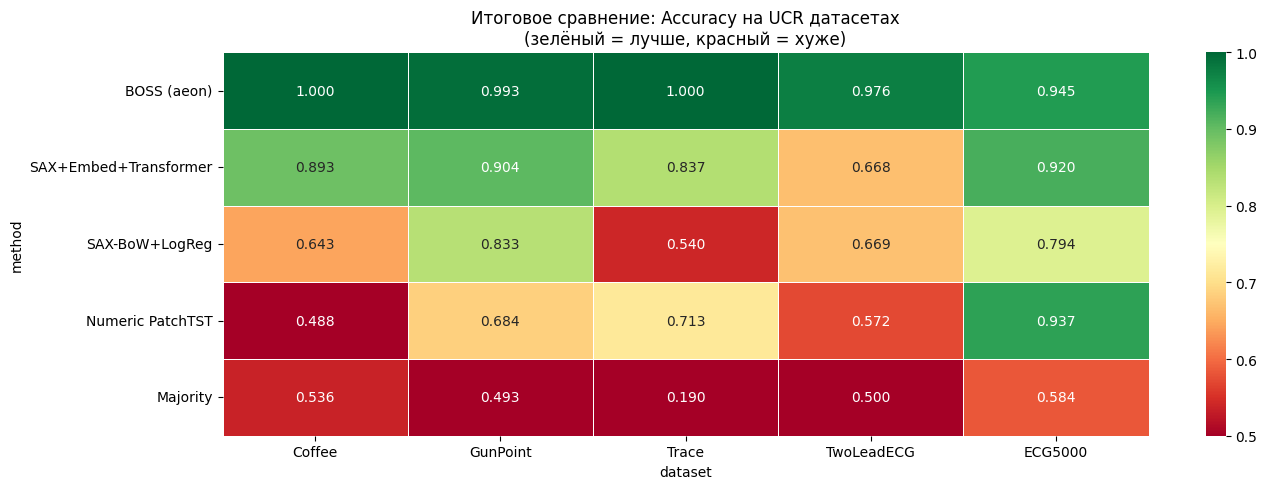


Итоговые ранги (1 = лучший):
dataset                Coffee  GunPoint   Trace  TwoLeadECG  ECG5000  Средний ранг
method                                                                            
BOSS (aeon)            1.0000    0.9933  1.0000      0.9763   0.9451           1.0
SAX+Embed+Transformer  0.8929    0.9044  0.8367      0.6675   0.9197           2.4
SAX-BoW+LogReg         0.6429    0.8333  0.5400      0.6690   0.7944           3.2
Numeric PatchTST       0.4881    0.6844  0.7133      0.5721   0.9365           3.6
Majority               0.5357    0.4933  0.1900      0.4996   0.5838           4.8


In [17]:
# Итоговая тепловая карта для UCR
ucr_df = all_df[all_df["experiment"] == "UCR"]
pivot_final = ucr_df.pivot_table(index="method", columns="dataset", values="accuracy", aggfunc="first")
pivot_final = pivot_final.reindex(columns=[c for c in UCR_DATASETS if c in pivot_final.columns])

# Ранги
ranks = pivot_final.rank(ascending=False, method="min")
pivot_final["Средний ранг"] = ranks.mean(axis=1)
pivot_final = pivot_final.sort_values("Средний ранг")

fig, ax = plt.subplots(figsize=(14, 5))
plot_data = pivot_final.drop(columns=["Средний ранг"])
sns.heatmap(plot_data, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0)
ax.set_title("Итоговое сравнение: Accuracy на UCR датасетах\n(зелёный = лучше, красный = хуже)")
plt.tight_layout()
plt.savefig("final_ucr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nИтоговые ранги (1 = лучший):")
print(pivot_final.round(4).to_string())

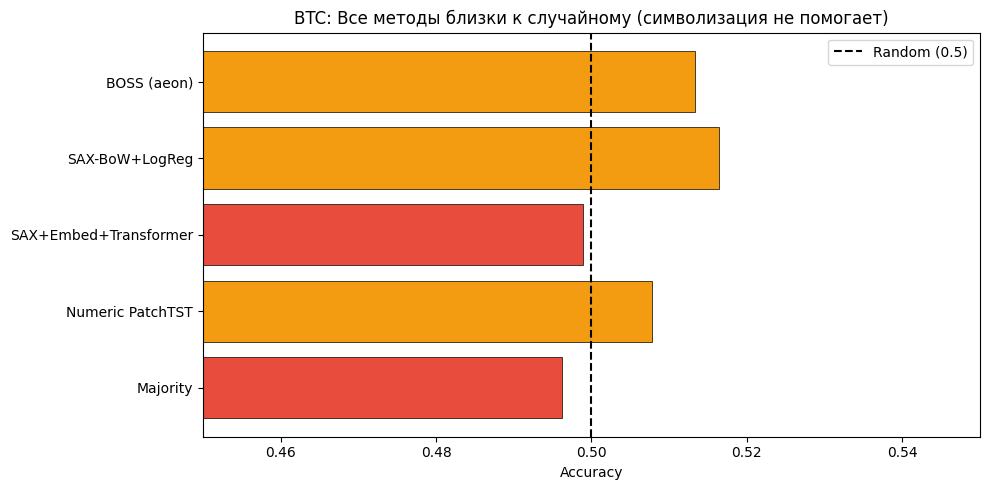

In [18]:
# Барплот для BTC
btc_df = all_df[all_df["experiment"] == "BTC"]
if len(btc_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    methods = btc_df["method"].values
    accs = btc_df["accuracy"].values
    colors = ["#2ecc71" if a > 0.52 else "#e74c3c" if a < 0.50 else "#f39c12" for a in accs]
    bars = ax.barh(methods, accs, color=colors, edgecolor="black", linewidth=0.5)
    ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Random (0.5)")
    ax.set_xlabel("Accuracy")
    ax.set_title("BTC: Все методы близки к случайному (символизация не помогает)")
    ax.set_xlim(0.45, 0.55)
    ax.legend()
    plt.tight_layout()
    plt.savefig("exp3_btc.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Выводы

### Когда символьное представление РАБОТАЕТ:
1. **Датасеты с повторяющимися паттернами** (ECG, Coffee, GunPoint, Trace) — BOSS показывает accuracy на уровне deep learning
2. **При высоком шуме** — символьные методы деградируют медленнее благодаря квантованию-как-фильтрации
3. **Словарный подход** (Bag-of-Patterns) лучше наивного "символы в трансформер"

### Когда символьное представление НЕ РАБОТАЕТ:
1. **Финансовые данные** (BTC) — слабый сигнал, нет структурных паттернов, квантование убивает различия
2. **Наивная символизация** без bag-of-patterns даёт результат хуже числового baseline

### Ключевые находки:
- Символьные методы типа BOSS конкурируют с deep learning на UCR **без GPU**
- Правильная архитектура символизации (fit на train, Embedding вместо float ID) критична
- Выбор между символьным и числовым подходом зависит от домена и характера данных